In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
def remove_unwanted_columns(df):
    """
    Removes specific unwanted columns if they exist in the DataFrame.
    """
    unwanted = [
        'Unnamed: 0', 'time_idx', 'Month', 'day_of_week', 
        'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date'
    ]
    cols_to_drop = [col for col in unwanted if col in df.columns]
    return df.drop(columns=cols_to_drop)


def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    """
    Ensures the dataframe has a continuous datetime index with no gaps.
    """
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)
    return df


def apply_physical_bounds(df):
    """
    Clips sensor data to realistic physical limits.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)
    return df


def handle_missing_values(df, max_gap=3):
    """
    Fills gaps using linear interpolation.
    'max_gap' limits interpolation so we don't 'guess' too much data.
    """
    df = df.interpolate(method='linear', limit=max_gap)
    df = df.ffill().bfill()
    return df

In [4]:
def load_and_preprocess_split(train_path, val_path, test_path):
    """
    Loads three CSVs, cleans them using the predefined pipeline,
    and returns scaled DataFrames + the fitted scaler.
    """
    datasets = {
        'train': pd.read_csv(train_path),
        'val':   pd.read_csv(val_path),
        'test':  pd.read_csv(test_path)
    }

    processed_dfs = {}

    for name, df in datasets.items():
        df_clean = (df.pipe(remove_unwanted_columns)
                      .pipe(fix_temporal_structure)
                      .pipe(apply_physical_bounds)
                      .pipe(handle_missing_values))
        processed_dfs[name] = df_clean

    # Fit scaler ONLY on train to prevent data leakage
    scaler = MinMaxScaler()
    feature_cols = processed_dfs['train'].columns
    scaler.fit(processed_dfs['train'][feature_cols])

    for name in processed_dfs:
        scaled_values = scaler.transform(processed_dfs[name][feature_cols])
        processed_dfs[name] = pd.DataFrame(
            scaled_values,
            columns=feature_cols,
            index=processed_dfs[name].index
        )

    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test'], scaler

In [5]:
train_data, val_data, test_data, fitted_scaler = load_and_preprocess_split(
    '../data/Train_data.csv',
    '../data/Validation_data.csv',
    '../data/Test_data.csv'
)

In [6]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0


In [7]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0


In [8]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.02508,0.347751,0.559211,0.0
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.02163,0.351402,0.534649,0.0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
print("Train columns:")
print(train_data.columns.tolist())

Train columns:
['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity', 'rainfall']


# Method 1: Predict PM2.5

In [11]:
target_col   = 'pm25'
feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [12]:
# FIX 1: Slice the 10 feature columns FIRST, then fit the scaler on them.
# Using fitted_scaler here would cause a column-count mismatch on inverse transform.
train_df = train_data[feature_cols].copy()
val_df   = val_data[feature_cols].copy()
test_df  = test_data[feature_cols].copy()

pm25_scaler = MinMaxScaler()
pm25_scaler.fit(train_df)   # fit ONLY on train

train_df = pd.DataFrame(pm25_scaler.transform(train_df), columns=feature_cols, index=train_df.index)
val_df   = pd.DataFrame(pm25_scaler.transform(val_df),   columns=feature_cols, index=val_df.index)
test_df  = pd.DataFrame(pm25_scaler.transform(test_df),  columns=feature_cols, index=test_df.index)

This creates input windows of past observations and predicts the next 24 PM2.5 values (24-hour horizon).

In [13]:
# FIX 2: horizon=24 so y contains the next 24 hours, matching Dense(24) output.
def create_sequences(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values    = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 10)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [14]:
lookback = 168   # past 7 days
horizon  = 24    # predict next 24 hours

X_train, y_train = create_sequences(train_df, target_col, lookback, horizon)
X_val,   y_val   = create_sequences(val_df,   target_col, lookback, horizon)
X_test,  y_test  = create_sequences(test_df,  target_col, lookback, horizon)

print("X_train:", X_train.shape)  # (samples, 168, 10)
print("y_train:", y_train.shape)  # (samples, 24)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (52393, 168, 10)
y_train: (52393, 24)
X_val:   (1225, 168, 10)
X_test:  (553, 168, 10)


In [15]:
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(horizon)   # outputs 24 values
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,552 (127.16 KB)

 Trainable params: 32,552 (127.16 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 117s 70ms/step - loss: 0.0040 - mae: 0.0401 - val_loss: 0.0043 - val_mae: 0.0470
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 113s 69ms/step - loss: 0.0031 - mae: 0.0353 - val_loss: 0.0039 - val_mae: 0.0447
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 113s 69ms/step - loss: 0.0029 - mae: 0.0339 - val_loss: 0.0038 - val_mae: 0.0437
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 112s 68ms/step - loss: 0.0028 - mae: 0.0333 - val_loss: 0.0037 - val_mae: 0.0438
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 117s 71ms/step - loss: 0.0027 - mae: 0.0328 - val_loss: 0.0035 - val_mae: 0.0422
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 118s 72ms/step - loss: 0.0026 - mae: 0.0323 - val_loss: 0.0035 - val_mae: 0.0425
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 117s 71ms/step - loss: 0.0025 - mae: 0.0319 - val_loss: 0.0033 - val_mae: 0.0413
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 116s 71ms/step - loss: 0.0025 - mae: 0.0318 - val_loss: 0.0034 - val_mae: 0.0421
Epoch 9/50
1638/

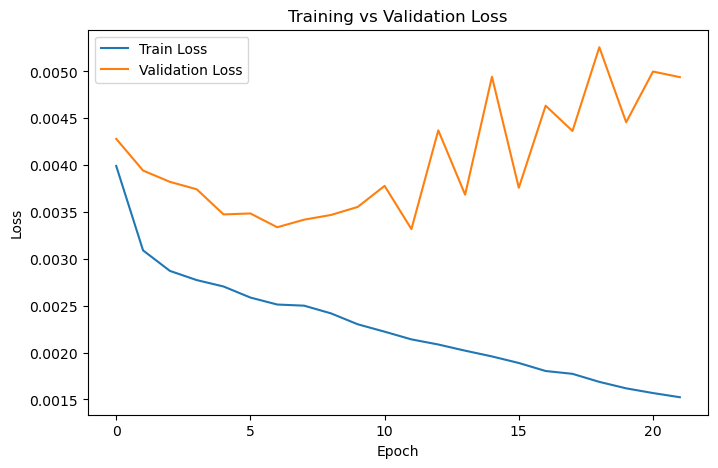

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [18]:
# FIX 3: No .flatten() — model.predict returns (samples, 24). Keep 2D shape.
y_pred_scaled = model.predict(X_test)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [19]:
def inverse_transform_target_only(scaler, y_scaled, feature_columns, target_col):
    """
    Inverse transforms only the target column.
    Works for both 1D (samples,) and 2D (samples, horizon) y_scaled.
    """
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_features = len(feature_columns)

    # Flatten to 1D, inverse transform, then reshape back
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()

    temp = np.zeros((len(y_flat), n_features))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]

    return inv.reshape(original_shape)

In [20]:
y_test_actual = inverse_transform_target_only(pm25_scaler, y_test,       feature_cols, target_col)
y_pred_actual = inverse_transform_target_only(pm25_scaler, y_pred_scaled, feature_cols, target_col)

# Both are shape (samples, 24) — real PM2.5 values
print("y_test_actual shape:", y_test_actual.shape)
print("y_pred_actual shape:", y_pred_actual.shape)

y_test_actual shape: (553, 24)
y_pred_actual shape: (553, 24)


In [25]:
y_pred_actual

array([[0.17622942, 0.18898682, 0.19606405, ..., 0.1313135 , 0.14770351,
        0.16231337],
       [0.1899586 , 0.20085105, 0.20745742, ..., 0.1497665 , 0.16269962,
        0.1732679 ],
       [0.2055487 , 0.21529248, 0.22149149, ..., 0.16209112, 0.17165756,
        0.17928362],
       ...,
       [0.05309502, 0.05290863, 0.05281353, ..., 0.04966681, 0.05021865,
        0.05115032],
       [0.05363719, 0.0534074 , 0.053285  , ..., 0.05009473, 0.0505883 ,
        0.05148238],
       [0.05496681, 0.05521747, 0.05543131, ..., 0.05033952, 0.0512602 ,
        0.05254308]], shape=(553, 24))

In [21]:
# FIX 4: Removed duplicate metrics cell. Flatten both arrays for overall metrics.
mae  = mean_absolute_error(y_test_actual.flatten(), y_pred_actual.flatten())
rmse = np.sqrt(mean_squared_error(y_test_actual.flatten(), y_pred_actual.flatten()))
r2   = r2_score(y_test_actual.flatten(), y_pred_actual.flatten())

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.0266
RMSE : 0.0352
R²   : 0.3823


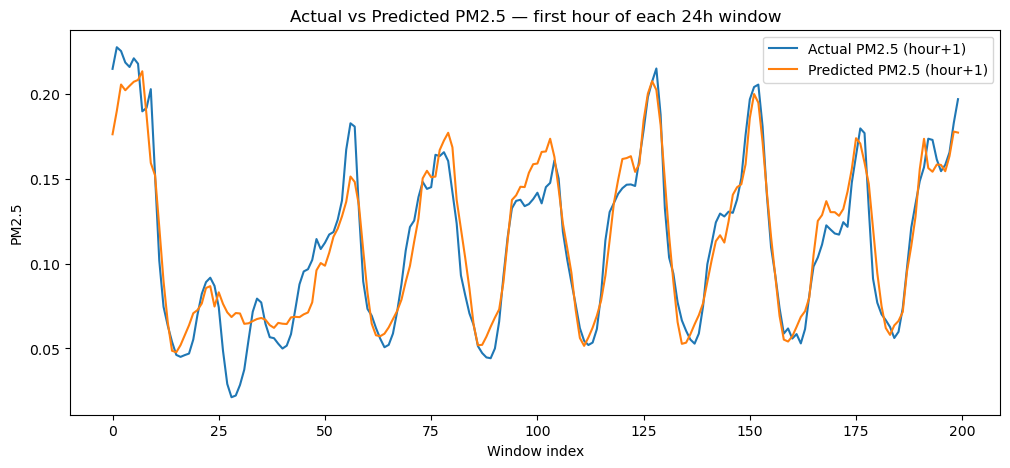

In [22]:
# Plot the first 200 predictions (hour 1 of each 24-hour window)
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200, 0], label='Actual PM2.5 (hour+1)')
plt.plot(y_pred_actual[:200, 0], label='Predicted PM2.5 (hour+1)')
plt.xlabel('Window index')
plt.ylabel('PM2.5')
plt.title('Actual vs Predicted PM2.5 — first hour of each 24h window')
plt.legend()
plt.show()

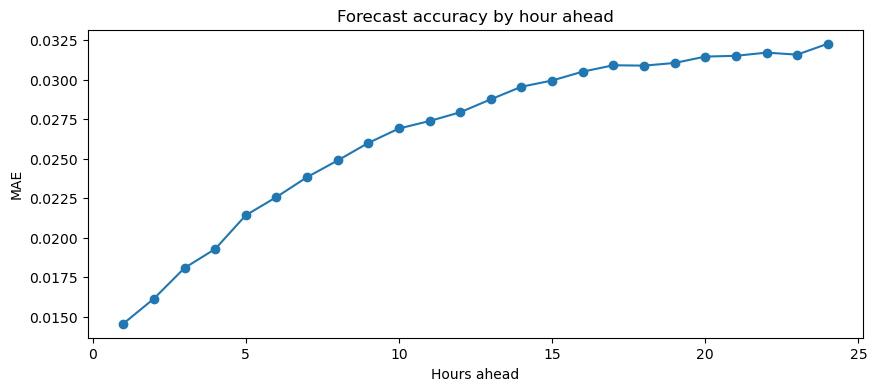

In [23]:
# Per-hour MAE across the 24-hour horizon
per_hour_mae = [mean_absolute_error(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'R² by hour ahead')

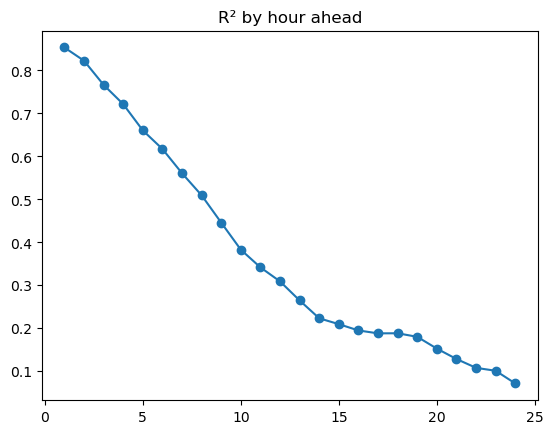

In [24]:
per_hour_r2 = [r2_score(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2, marker='o')
plt.title('R² by hour ahead')

# Method 2: Predict NO2

# Method 3: Predict CO

# Method 4: Predict Ozone

# Method 5: Predict All (Multi-variate / Multi-task)